In [1]:
from IPython.display import HTML, clear_output
import xarray as xr

from mcs_prime import mcs_prime_config_util as cu

In [2]:
import sys
sys.path.insert(0, '/home/users/mmuetz/projects/mcs_prime_stoch_trigger/ctrl/remakefiles')
from ASoPlite import ASoPlite

In [3]:
imerg_N216_path = '/gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_output/imerg_processed/N216grid/2020-07-01_04:00:00-2020-07-11_03:00:00/3B-HHR.MS.MRG.3IMERG.2020-07-01_04:00:00-2020-07-11_03:00:00.hourly.V07B.nc'
imerg_N216 = xr.load_dataarray(imerg_N216_path)
imerg_N216_wp_3h = imerg_N216.sel(longitude=slice(60, 160), latitude=slice(-10, 10)).coarsen(time=3).mean()

In [4]:
datadir = cu.PATHS['datadir']
simdir = datadir / 'UM_sims'

EXPTS = {
    'ctrl': 'u-di727',    
    'vanillaMCSP': 'u-di728',    
    'stochMCSP': 'u-dg135',
}
nens = 10

In [5]:
expt_pflux = {}
for expt, suite in EXPTS.items():
    pflux_path = simdir / f'{suite}/processed/{expt}/engla_pa.precip.nc'
    pflux = xr.load_dataarray(pflux_path)
    pflux.values *= 3600 
    pflux.attrs['units'] = 'mm h-1'
    expt_pflux[expt] = pflux


In [6]:
print('WHAT??? WHY ARE THESE THE SAME???')
(expt_pflux['ctrl'].sel(ens_mem=0).values == expt_pflux['stochMCSP'].sel(ens_mem=0).values).all()

WHAT??? WHY ARE THESE THE SAME???


True

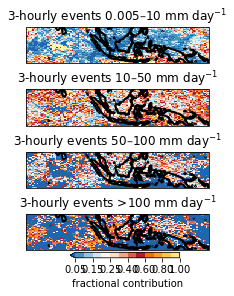

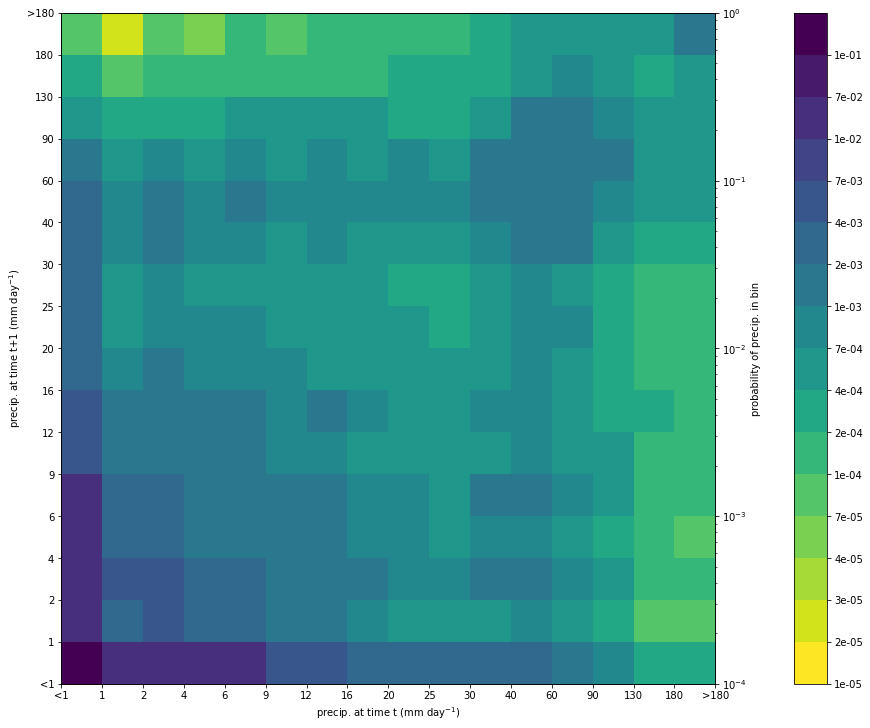

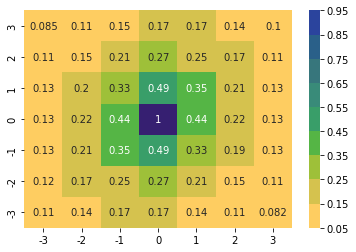

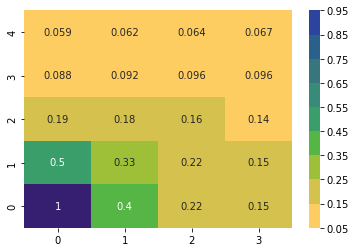

In [7]:
asop_imerg_wp = ASoPlite(imerg_N216_wp_3h, '3-hourly')
asop_imerg_wp.calc_all()
clear_output()
asop_imerg_wp.plot_all()

In [9]:
asop_imerg_wp.ds.to_netcdf('asop_imerg_wp.nc')

In [10]:
asop_imerg_wp2 = ASoPlite(imerg_N216_wp_3h, '3-hourly')
asop_imerg_wp2.load_ds(xr.load_dataset('asop_imerg_wp.nc'))


In [13]:
asop_imerg_wp.precip_prob_hist

array([0.71875   , 0.04313368, 0.04814236, 0.02887153, 0.02740741,
       0.01876736, 0.01742187, 0.0127228 , 0.01202836, 0.00937789,
       0.01388021, 0.01707176, 0.01388889, 0.00878762, 0.00487847,
       0.00486979])

In [16]:
asop_imerg_wp.ds.precip_prob_hist

<xarray.DataArray 'precip_prob_hist' (precip_bin_lower: 4)>
array([nan, nan, nan, nan])
Coordinates:
  * precip_bin_lower  (precip_bin_lower) float64 0.005 10.0 50.0 100.0

In [17]:
xr.DataArray(
    asop_imerg_wp.precip_prob_hist,
    dims='precip_bin_lower',
    coords=dict(precip_bin_lower=('precip_bin_lower', asop_imerg_wp.precip_prob_matrix_bins_mmpday[:-1], {'units': 'mm day-1'})),
)


<xarray.DataArray (precip_bin_lower: 16)>
array([0.71875   , 0.04313368, 0.04814236, 0.02887153, 0.02740741,
       0.01876736, 0.01742187, 0.0127228 , 0.01202836, 0.00937789,
       0.01388021, 0.01707176, 0.01388889, 0.00878762, 0.00487847,
       0.00486979])
Coordinates:
  * precip_bin_lower  (precip_bin_lower) int64 0 1 2 4 6 9 ... 40 60 90 130 180

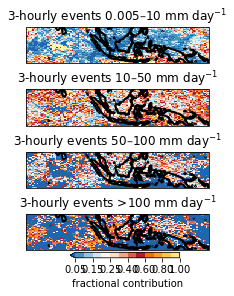

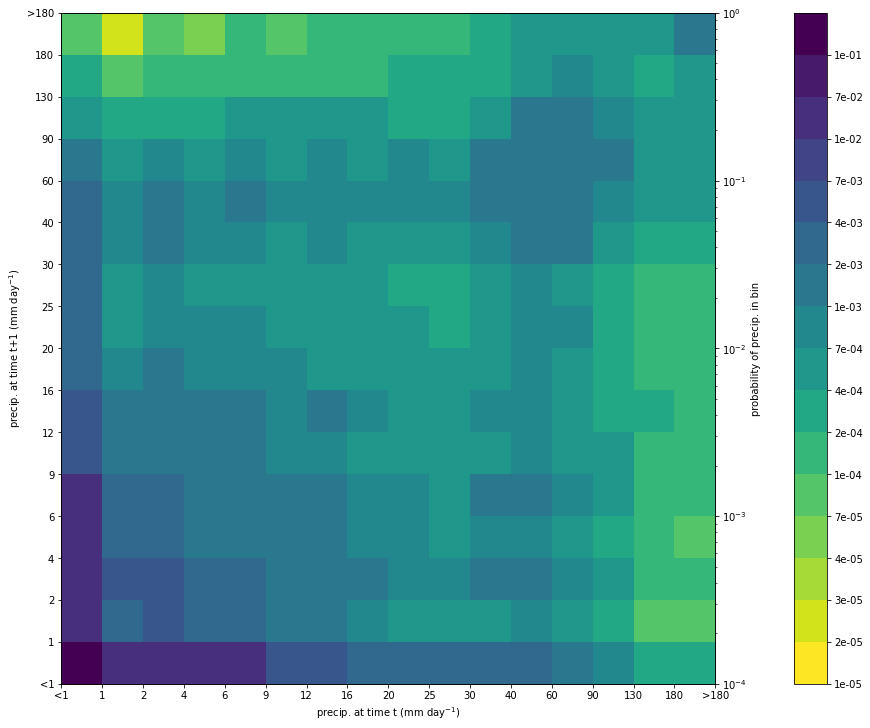

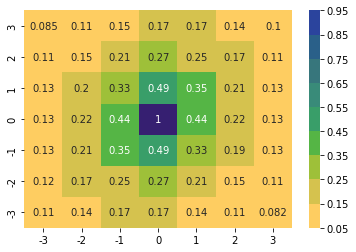

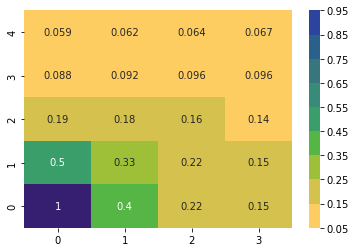

In [11]:
asop_imerg_wp2.plot_all()

In [8]:
expt_asops = {}
for expt in EXPTS:
    print(expt)
    expt_wp_3h = expt_pflux[expt].sel(ens_mem=1).sel(longitude=slice(60, 160), latitude=slice(-10, 10)).coarsen(time=3).mean()
    asop = ASoPlite(expt_wp_3h, '3-hourly')
    asop.calc_all()
    expt_asops[expt] = asop
    clear_output()

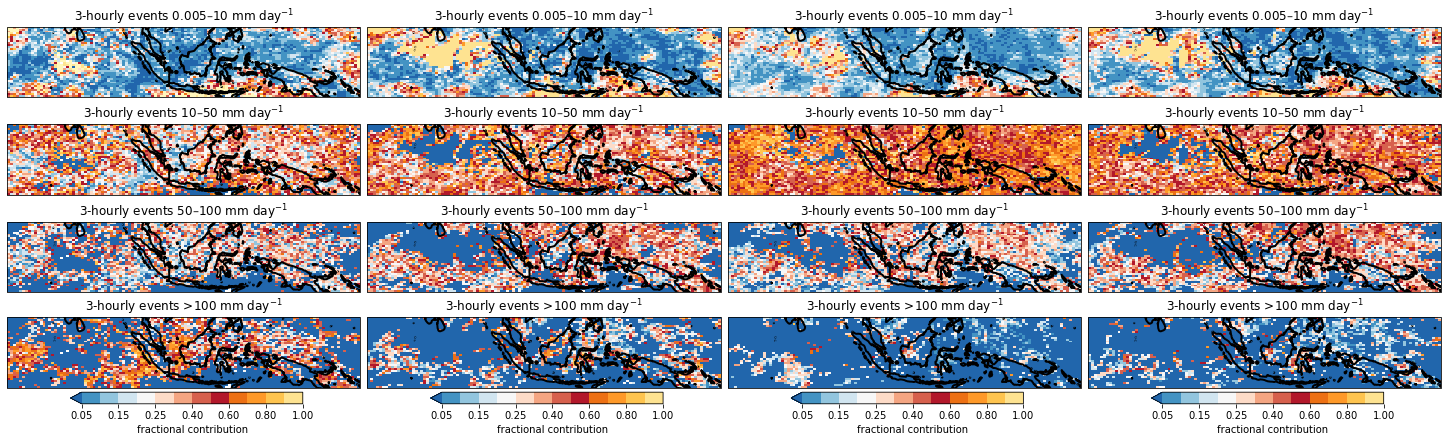

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
fig, axes = plt.subplots(4, 4, layout='constrained', subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_size_inches(20, 6)
asops = {**{'imerg': asop_imerg_wp}, **expt_asops}
for axcol, (expt, asop) in zip(axes.T, asops.items()):
    asop.plot_fractional_contrib(axes=axcol)


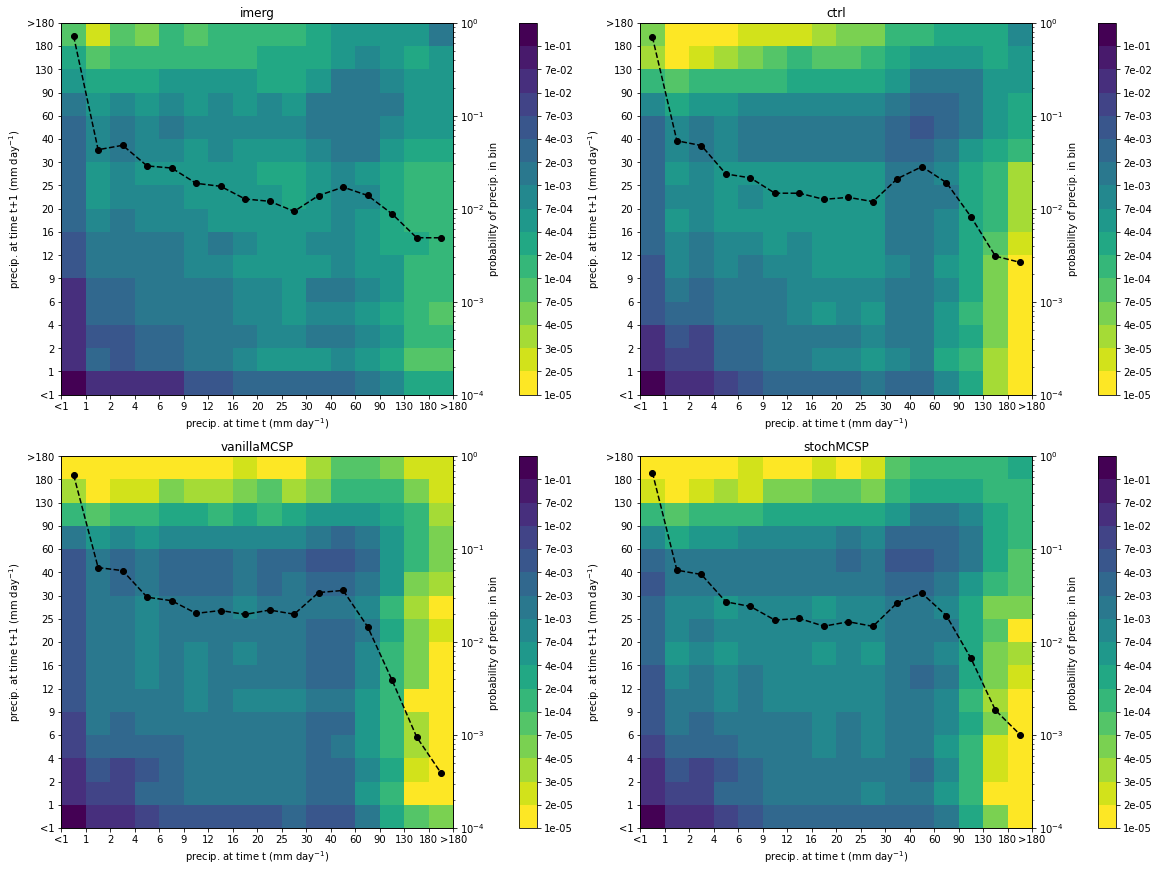

In [10]:
fig, axes = plt.subplots(2, 2, layout='constrained')
fig.set_size_inches(16, 12)
for ax, (expt, asop) in zip(axes.flatten(), asops.items()):
    asop.plot_precip_prob_matrix(ax=ax)
    fig = plt.gcf()
    ax.set_title(expt)

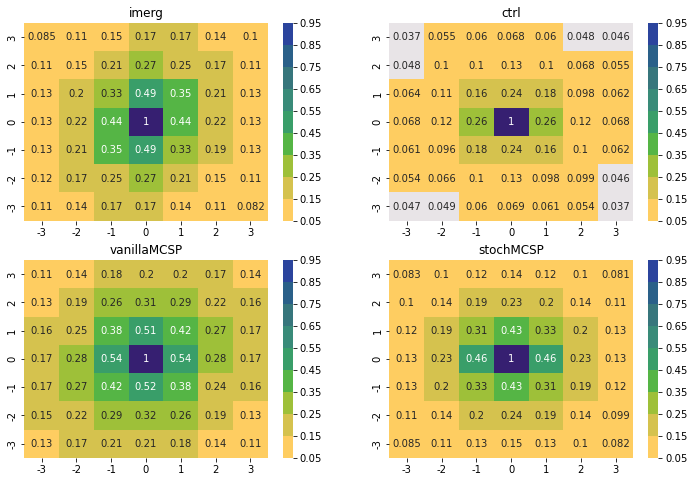

In [11]:
fig, axes = plt.subplots(2, 2)
fig.set_size_inches(12, 8)
for ax, (expt, asop) in zip(axes.flatten(), asops.items()):
    asop.plot_7x7_spat_corr(ax=ax)
    ax.set_title(expt)

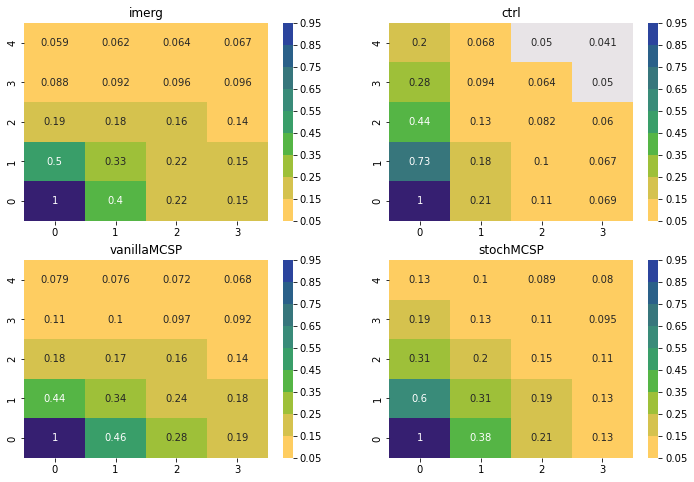

In [12]:
fig, axes = plt.subplots(2, 2)
fig.set_size_inches(12, 8)
for ax, (expt, asop) in zip(axes.flatten(), asops.items()):
    asop.plot_7x7_spat_temp_corr(ax=ax)
    ax.set_title(expt)
#     fig = plt.gcf()
#     plt.suptitle(expt)


In [13]:
asops['ctrl'].precip_prob_matrix == asops['stochMCSP'].precip_prob_matrix

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, Fals